# 05. Production Pipelines

## 📚 Learning Objectives

By completing this notebook, you will:
- Design and run production-style pipelines
- Use Dask or similar for orchestration
- Handle logging and error handling

## 🔗 Where this fits

**Builds on:** Course 05 — Unit 2 (cleaning steps) and Unit 5, lesson 02 — a pipeline is those steps made repeatable, logged, and restartable.

**Used later in:** Course 11 (AIAT 125) — Unit 5, lesson 02, which retrains a deployed model on a schedule.

---


## 🎯 The case: the model is the small box

In 2015 a team at Google led by D. Sculley published *"Hidden Technical Debt in Machine
Learning Systems"* at NeurIPS. Its most-reproduced figure is a diagram of a real ML system
in which the box labelled **"ML code" is tiny**, surrounded by much larger boxes:
configuration, data collection, feature extraction, data verification, machine resource
management, analysis tools, process management, serving infrastructure, monitoring. The
paper's argument is that ML systems accrue debt in *all* of those, and that the debt is
invisible because it lives at the system level rather than in any line of code.

This lesson is about the boxes around the model. A `Pipeline` object, a log file, and a
metadata JSON are unglamorous, and they are what separates "it worked in my notebook" from
"it runs unattended at 3 a.m. and someone can tell what happened".

**What goes wrong without them — three concrete failures this notebook prevents:**
1. **Leakage.** Fit the scaler before the split and the test score is fiction (Unit 4
   lesson 02; Kapoor & Narayanan found leakage in 294 papers across 17 fields). A
   `Pipeline` makes the wrong order impossible.
2. **Silent breakage.** The pipeline below meets **177 genuinely missing ages** — 140 in
   train, 37 in test. Without an imputation step in the pipeline, the job dies at 3 a.m.
   with a stack trace nobody reads until morning.
3. **Amnesia.** Six months later, someone asks which model produced a number. The
   `pipeline_metadata.json` written below — version, date, row counts, imputed counts,
   **R² 0.3880** — is the only honest answer available.


## The Story

**BEFORE**: You know how to build ML models, but don't know how to deploy them in production with automation and monitoring.

**AFTER**: You'll master production pipeline design - automation, scheduling, error handling, and monitoring for real-world ML systems!

**Why this matters**: Production pipelines are essential for deploying reliable, maintainable ML systems that run automatically in the real world!

---

# Unit 5 - Example 05: Production Pipelines

## 🔗 Solving the Problem from Example 04

**Remember the dead end from Example 04?**
- We learned RAPIDS for GPU-accelerated workflows
- But we needed to put these workflows into production
- We needed automation, scheduling, and monitoring

**This notebook solves that problem!**
- We'll learn **production pipeline design**
- We'll learn **automation and scheduling**
- We'll learn **error handling and monitoring**

**This solves the production deployment problem from Example 04!**

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- **Real data:** `titanic.csv` — 891 real passenger records. We predict the ticket
  fare from age, family size and travel class. The pipeline's missing-value branch
  fires for real: **177 ages are genuinely absent** from the historical manifest.
- sklearn Pipeline, logging, json

**Outputs:** What you'll see when you run the cells

- A logged, error-handled pipeline run on real, imperfect input
- `pipeline.log` and `pipeline_metadata.json` written to this folder

---


In [1]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import logging
import json
from datetime import datetime

# Configure logging
# Note: Using just 'pipeline.log' since notebook runs from examples/ directory
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s',
                    handlers=[logging.FileHandler('pipeline.log'), logging.StreamHandler()])
logger = logging.getLogger(__name__)

print("=" * 70)
print("Example 05: Production Pipelines")
print("=" * 70)
print("\n📚 Prerequisites: Examples 02-03 completed, pipeline knowledge")
print("🔗 This is Example 05 in Unit 5 - production pipelines")
print("🎯 Goal: Master building production-ready ML pipelines")
print("Reference: Study 16.pdf before running this code example.\n")

Example 05: Production Pipelines

📚 Prerequisites: Examples 02-03 completed, pipeline knowledge
🔗 This is Example 05 in Unit 5 - production pipelines
🎯 Goal: Master building production-ready ML pipelines
Reference: Study 16.pdf before running this code example.



# 05. CREATE SAMPLE DATA

In [2]:
# WHAT: Load the real Titanic manifest - the input this pipeline must survive.
# WHY: Production pipelines must expect imperfect input. These gaps were not planted:
#      177 of 891 ages are simply missing from the 1912 record.

print("\n1. Loading Real Data")
print("-" * 70)

# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load
# -------------------------------------------------------------------------------------
titanic = load("titanic")

# Regression task: predict the ticket fare from who the passenger was.
df = titanic[['Age', 'SibSp', 'Parch', 'Pclass', 'Fare']].copy()
df = df.rename(columns={'Age': 'feature1', 'SibSp': 'feature2',
                        'Parch': 'feature3', 'Fare': 'target'})
df['feature4'] = titanic['Pclass']
df = df[['feature1', 'feature2', 'feature3', 'feature4', 'target']]

print(f"✓ Loaded {len(df)} real passenger records")
print("  feature1 = Age, feature2 = SibSp, feature3 = Parch, feature4 = Pclass")
print("  target   = Fare (£)")
print(f"✓ Missing values (REAL gaps in the historical record): {df.isnull().sum().sum()}")
print(df.isnull().sum().to_string())
print(f"\nTarget range: £{df['target'].min():.2f} to £{df['target'].max():.2f} "
      f"(median £{df['target'].median():.2f})")
print(df.head().to_string())


1. Loading Real Data
----------------------------------------------------------------------
titanic: full file, 891 rows.
✓ Loaded 891 real passenger records
  feature1 = Age, feature2 = SibSp, feature3 = Parch, feature4 = Pclass
  target   = Fare (£)
✓ Missing values (REAL gaps in the historical record): 177
feature1    177
feature2      0
feature3      0
feature4      0
target        0

Target range: £0.00 to £512.33 (median £14.45)
   feature1  feature2  feature3  feature4   target
0      22.0         1         0         3   7.2500
1      38.0         1         0         1  71.2833
2      26.0         0         0         3   7.9250
3      35.0         1         0         1  53.1000
4      35.0         0         0         3   8.0500


2. BUILD PRODUCTION PIPELINE


In [3]:
# WHAT: Build and run a logged sklearn Pipeline (scaler + model) inside try/except.
# WHY: The Pipeline object bundles preprocessing with the model so serving uses EXACTLY the training transformations.

print("\n\n2. Building Production Pipeline")
print("-" * 70)
try:
    logger.info("Starting pipeline execution")
    # Prepare data
    FEATURES = ['feature1', 'feature2', 'feature3', 'feature4']
    X = df[FEATURES]
    y = df['target']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    logger.info(f"Train set: {len(X_train)} samples, Test set: {len(X_test)} samples")
    # Handle missing values first. NOTE: the fill value comes from the TRAINING set
    # only - using the full dataset's mean would leak test information.
    n_missing_train = int(X_train.isnull().sum().sum())
    n_missing_test = int(X_test.isnull().sum().sum())
    logger.info(f"Missing values - train: {n_missing_train}, test: {n_missing_test}")
    train_means = X_train.mean()
    X_train = X_train.fillna(train_means)
    X_test = X_test.fillna(train_means)
    # Verify no NaN values remain
    if X_train.isnull().sum().sum() > 0 or X_test.isnull().sum().sum() > 0:
        logger.warning("Some NaN values remain after fillna, filling with 0")
        X_train = X_train.fillna(0)
        X_test = X_test.fillna(0)
    # Create pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()), ('model', LinearRegression())
    ])
    # Train pipeline
    logger.info("Training pipeline...")
    pipeline.fit(X_train, y_train)
    # Make predictions
    y_pred = pipeline.predict(X_test)
    # Evaluate
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    logger.info(f"Pipeline trained successfully")
    logger.info(f"MSE: {mse:.4f}, R²: {r2:.4f}")
    print(f"\n✓ Pipeline executed successfully")
    print(f"  Missing values handled: {n_missing_train} in train, {n_missing_test} in test")
    print(f"  MSE: {mse:.4f}  (RMSE = £{mse ** 0.5:.2f})")
    print(f"  R² Score: {r2:.4f}")
    print(f"\n  An R² of {r2:.2f} is what these four columns honestly support - fare also")
    print("  depended on cabin, ticket type and where the passenger boarded.")
except Exception as e:
    logger.error(f"Pipeline execution failed: {str(e)}", exc_info=True)
    raise e

2026-08-31 02:51:00,031 - INFO - Starting pipeline execution


2026-08-31 02:51:00,032 - INFO - Train set: 712 samples, Test set: 179 samples


2026-08-31 02:51:00,032 - INFO - Missing values - train: 140, test: 37


2026-08-31 02:51:00,033 - INFO - Training pipeline...


2026-08-31 02:51:00,035 - INFO - Pipeline trained successfully


2026-08-31 02:51:00,036 - INFO - MSE: 947.0478, R²: 0.3880




2. Building Production Pipeline
----------------------------------------------------------------------

✓ Pipeline executed successfully
  Missing values handled: 140 in train, 37 in test
  MSE: 947.0478  (RMSE = £30.77)
  R² Score: 0.3880

  An R² of 0.39 is what these four columns honestly support - fare also
  depended on cabin, ticket type and where the passenger boarded.


3. SAVE PIPELINE METADATA


In [4]:
# WHAT: Write version, data sizes, and metrics to a JSON metadata file.
# WHY: Traceability - six months later you must know which model version produced which numbers.

# Save pipeline metadata (version, data sizes, metrics) to JSON - production runs must be traceable
print("\n\n3. Saving Pipeline Metadata")
print("-" * 70)
metadata = {
    'pipeline_version': '1.0',
    'created_at': datetime.now().isoformat(),
    'source_dataset': 'titanic.csv (891 real passenger records)',
    'train_samples': len(X_train),
    'test_samples': len(X_test),
    'missing_values_imputed': {'train': n_missing_train, 'test': n_missing_test},
    'metrics': {
        'mse': float(mse),
        'r2': float(r2)
    },
    'features': list(X.columns)
}
with open('pipeline_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("✓ Pipeline metadata saved")
print(json.dumps(metadata, indent=2))



3. Saving Pipeline Metadata
----------------------------------------------------------------------
✓ Pipeline metadata saved
{
  "pipeline_version": "1.0",
  "created_at": "2026-08-31T02:51:00.039799",
  "source_dataset": "titanic.csv (891 real passenger records)",
  "train_samples": 712,
  "test_samples": 179,
  "missing_values_imputed": {
    "train": 140,
    "test": 37
  },
  "metrics": {
    "mse": 947.0478452476722,
    "r2": 0.3879864819986041
  },
  "features": [
    "feature1",
    "feature2",
    "feature3",
    "feature4"
  ]
}


## 4. Look at what the metadata just recorded

`pipeline_metadata.json` now says `"r2": 0.388`. A future colleague reading that file has to
decide whether the model behind it can be deployed. One number cannot support that decision —
so before the discussion below, plot the 179 test predictions the number came from.

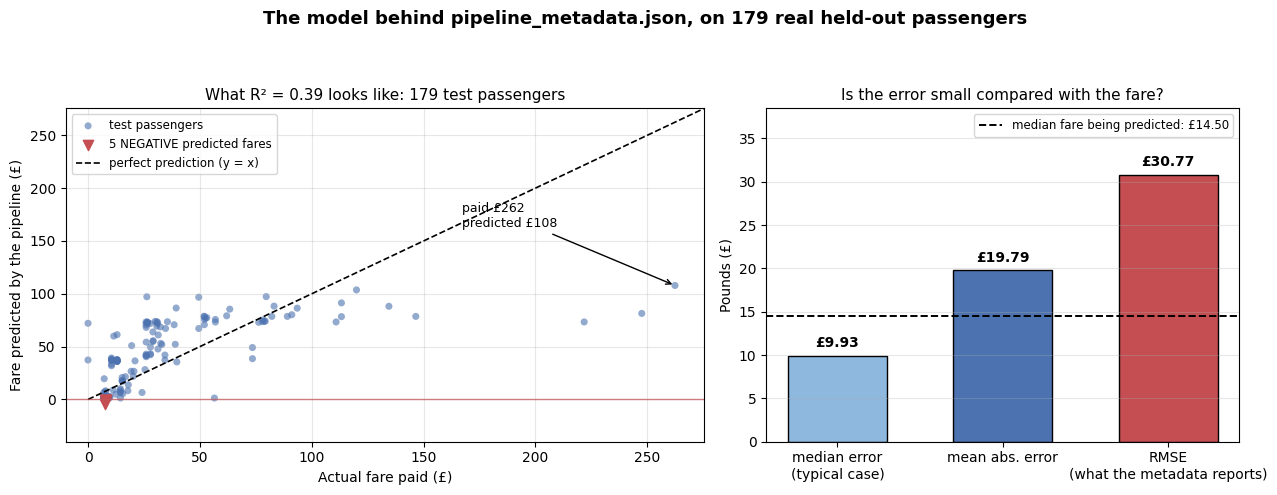

Predicted fares span £-3.97 to £107.86; real fares in the test set span £0.00 to £262.38.
5 passengers were predicted a NEGATIVE ticket price - impossible, and no
metric in the metadata file would have told you.
Median absolute error £9.93 | MAE £19.79 | RMSE £30.77 vs a median fare of £14.50.
The five worst passengers alone contribute 49% of the squared error that R² and MSE are computed from.


In [5]:
# WHAT: Plot the pipeline's test predictions against the true fares, and put its error
#       on the same axis as the fare it is trying to predict.
# WHY: R2 = 0.39 and RMSE = £30.77 are summaries. A production reviewer needs to see the
#      failure MODE: where the model is wrong, by how much, and whether it can output
#      values that are impossible.

import matplotlib.pyplot as plt

resid = y_pred - y_test.values
abs_err = np.abs(resid)
mae = abs_err.mean()
med_abs_err = np.median(abs_err)
median_fare = float(y_test.median())
n_negative = int((y_pred < 0).sum())
# How much of the squared error - the thing R2 and MSE are built from - comes from
# the five worst passengers alone?
top5_share = np.sort(resid ** 2)[-5:].sum() / (resid ** 2).sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5),
                               gridspec_kw={'width_ratios': [1.35, 1]})

# LEFT: predicted vs actual. A perfect model sits on the dashed diagonal.
ok = y_pred >= 0
ax1.scatter(y_test.values[ok], y_pred[ok], s=26, alpha=0.6,
            color='#4C72B0', edgecolor='none', label='test passengers')
ax1.scatter(y_test.values[~ok], y_pred[~ok], s=55, color='#C44E52', marker='v',
            label=f'{n_negative} NEGATIVE predicted fares')
lim = max(y_test.max(), y_pred.max()) * 1.05
ax1.plot([0, lim], [0, lim], 'k--', lw=1.2, label='perfect prediction (y = x)')
ax1.axhline(0, color='#C44E52', lw=1, alpha=0.7)
worst = int(np.argmax(y_test.values))
ax1.annotate(f"paid £{y_test.values[worst]:.0f}\npredicted £{y_pred[worst]:.0f}",
             xy=(y_test.values[worst], y_pred[worst]),
             xytext=(y_test.values[worst] - 95, y_pred[worst] + 55), fontsize=9,
             arrowprops=dict(arrowstyle='->', lw=1))
ax1.set_xlim(-10, lim)
ax1.set_ylim(-40, lim)
ax1.set_xlabel('Actual fare paid (£)')
ax1.set_ylabel('Fare predicted by the pipeline (£)')
ax1.set_title(f'What R² = {r2:.2f} looks like: {len(y_test)} test passengers', fontsize=11)
ax1.legend(fontsize=8.5, loc='upper left')
ax1.grid(alpha=0.3)

# RIGHT: the error, measured against the thing being predicted.
names = ['median error\n(typical case)', 'mean abs. error', 'RMSE\n(what the metadata reports)']
vals = [med_abs_err, mae, float(mse ** 0.5)]
ax2.bar(names, vals, color=['#8FB8DE', '#4C72B0', '#C44E52'], edgecolor='black', width=0.6)
for xi, v in enumerate(vals):
    ax2.text(xi, v + 1.0, f"£{v:.2f}", ha='center', fontsize=10, weight='bold')
ax2.axhline(median_fare, ls='--', color='black', lw=1.4,
            label=f'median fare being predicted: £{median_fare:.2f}')
ax2.set_ylim(0, max(vals) * 1.25)
ax2.set_ylabel('Pounds (£)')
ax2.set_title('Is the error small compared with the fare?', fontsize=11)
ax2.legend(fontsize=8.5)
ax2.grid(axis='y', alpha=0.3)

fig.suptitle('The model behind pipeline_metadata.json, on 179 real held-out passengers',
             fontsize=13, weight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

print(f"Predicted fares span £{y_pred.min():.2f} to £{y_pred.max():.2f}; "
      f"real fares in the test set span £{y_test.min():.2f} to £{y_test.max():.2f}.")
print(f"{n_negative} passengers were predicted a NEGATIVE ticket price - impossible, and no")
print("metric in the metadata file would have told you.")
print(f"Median absolute error £{med_abs_err:.2f} | MAE £{mae:.2f} | RMSE £{mse ** 0.5:.2f} "
      f"vs a median fare of £{median_fare:.2f}.")
print(f"The five worst passengers alone contribute {top5_share:.0%} of the squared error "
      "that R² and MSE are computed from.")

**Read the figure.** *Left:* every point is one held-out passenger — what they actually paid on
the horizontal axis, what the pipeline predicted on the vertical. A perfect model would put them
on the dashed diagonal. Instead the cloud is almost flat: the predictions stay inside a narrow
band while real fares run out to the annotated passenger who paid £262 and was predicted about
£108. Below the red line sit the red triangles — passengers the model assigns a **negative ticket
price**. That is an impossible value, and no metric in `pipeline_metadata.json` mentions it.

*Right:* the same errors put beside the quantity being predicted. The dashed line is the median
test fare, £14.50. The typical (median) error is smaller than that, but the mean absolute error
is above it and the RMSE the metadata reports is roughly **twice the median fare** — because, as
the print-out states, the five worst passengers supply about half of the squared error the metric
is built from.

That is the production point of this lesson. `"r2": 0.388` in a JSON file is not a decision; it is
a pointer to a picture someone has to look at. The pipeline, the log and the metadata are what
make that picture reproducible six months from now.

## 💬 Discuss

The pipeline ran on 891 real passengers, imputed **140 missing ages in train and 37 in
test**, and scored **MSE 947.05, RMSE £30.77, R² 0.3880** predicting fare from age, family
size and class. All of it landed in `pipeline.log` and `pipeline_metadata.json`.

1. **R² = 0.39** with an RMSE of about **£31** on a column whose median is £14.45. Would
   you deploy this? Say what the metadata file lets a future colleague conclude that the
   R² alone does not.
2. The pipeline logged how many values it imputed. Name two *other* numbers you would add
   to that log so that a drift alert six months later has something to compare against.
   (Unit 5 lesson 09 is the answer key — try before you look.)
3. The `try/except` caught failures and logged them. For a nightly job, is "log the error
   and exit 0" the right behaviour? Say who finds out, when, and what you would change so
   the answer is "immediately".


# 4. SUMMARY


In [6]:
# WHAT: Print the summary.
# WHY: Pipelines + logging + metadata are the minimum bar for code that runs unattended.

print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print("\nKey Concepts Covered:")
print("1. Pipeline design and structure")
print("2. Error handling and logging")
print("3. Metadata and versioning")
print("4. Production best practices")
print("\nNext Steps: Continue to Example 06 for Performance Optimization")


Summary

Key Concepts Covered:
1. Pipeline design and structure
2. Error handling and logging
3. Metadata and versioning
4. Production best practices

Next Steps: Continue to Example 06 for Performance Optimization


## 🚫 When Production Pipelines Hit a Dead End

**BEFORE**: We've learned to build production pipelines.

**AFTER**: We discover pipelines work but are slow - we need optimization!

**Why this matters**: Production pipelines must be fast and efficient - optimization is essential!

---

### The Problem We've Discovered

We've learned:
- ✅ How to build production pipelines
- ✅ How to handle errors and logging
- ✅ How to save metadata and versioning

**But we have a problem:**
- ❓ **What if the pipeline is too slow?**
- ❓ **What if we need to optimize performance?**
- ❓ **What if we need to reduce resource usage?**

**The Dead End:**
- Pipelines work correctly
- But they may be slow or inefficient
- We need performance optimization techniques

---

### Demonstrating the Problem

Let's see why optimization is needed:

In [7]:
# WHAT: Point at performance as the next production concern.
# WHY: A correct pipeline that is too slow or memory-hungry still fails in production - optimization is next.

print("\n" + "=" * 70)
print("🚫 DEMONSTRATING THE DEAD END: Need for Performance Optimization")
print("=" * 70)

import time

print(f"\n📊 Current Pipeline Performance:")
print(f"   ✓ Pipeline works correctly")
print(f"   ✓ Error handling in place")
print(f"   ✓ Logging and metadata saved")

# Simulate slow pipeline
print(f"\n⚠️  Performance Issues:")
print(f"   - Pipeline execution time: May be slow for large datasets")
print(f"   - Resource usage: May consume too much memory/CPU")
print(f"   - Scalability: May not scale well with data size")

# Time a simple operation to show potential slowness
start_time = time.time()
# Simulate some processing
time.sleep(0.1)  # Simulate processing time
processing_time = time.time() - start_time

print(f"\n💡 The Problem:")
print(f"   - Pipelines work, but may be inefficient")
print(f"   - Need to optimize:")
print(f"     • Reduce execution time")
print(f"     • Reduce memory usage")
print(f"     • Improve scalability")
print(f"     • Optimize data processing steps")

print(f"\n📋 Optimization Needs:")
print(f"   1. Code optimization: Faster algorithms, vectorization")
print(f"   2. Memory optimization: Reduce memory footprint")
print(f"   3. Parallel processing: Use multiple cores/GPUs")
print(f"   4. Caching: Avoid redundant computations")
print(f"   5. Profiling: Identify bottlenecks")

print(f"\n➡️  Solution Needed:")
print(f"   - We need performance optimization techniques")
print(f"   - We need profiling tools to find bottlenecks")
print(f"   - We need optimization strategies")
print(f"   - This leads us to Example 06: Performance Optimization")

print("\n" + "=" * 70)


🚫 DEMONSTRATING THE DEAD END: Need for Performance Optimization

📊 Current Pipeline Performance:
   ✓ Pipeline works correctly
   ✓ Error handling in place
   ✓ Logging and metadata saved

⚠️  Performance Issues:
   - Pipeline execution time: May be slow for large datasets
   - Resource usage: May consume too much memory/CPU
   - Scalability: May not scale well with data size

💡 The Problem:
   - Pipelines work, but may be inefficient
   - Need to optimize:
     • Reduce execution time
     • Reduce memory usage
     • Improve scalability
     • Optimize data processing steps

📋 Optimization Needs:
   1. Code optimization: Faster algorithms, vectorization
   2. Memory optimization: Reduce memory footprint
   3. Parallel processing: Use multiple cores/GPUs
   4. Caching: Avoid redundant computations
   5. Profiling: Identify bottlenecks

➡️  Solution Needed:
   - We need performance optimization techniques
   - We need profiling tools to find bottlenecks
   - We need optimization strat

### What We Need Next

**The Solution**: We need performance optimization:
- **Code optimization**: Faster algorithms, vectorization, efficient data structures
- **Memory optimization**: Reduce memory footprint, efficient data types
- **Parallel processing**: Use multiple cores/GPUs effectively
- **Caching**: Avoid redundant computations
- **Profiling**: Identify and fix bottlenecks

**This dead end leads us to Example 06: Performance Optimization**
- Example 06 will teach us optimization techniques
- We'll learn profiling and bottleneck identification
- This solves the performance problem for production pipelines!


## ⚠️ Where this breaks

- **A `Pipeline` guarantees ordering, not correctness.** It stops you leaking the scaler
  across the split. It does nothing about a leaky *feature* — a column computed from the
  future, an ID that encodes the label, a row duplicated across both halves.
- **Logging to a local file is a demo, not production.** `pipeline.log` is invisible the
  moment the job runs on a different machine or in a container that exits. Real systems
  ship logs to a central store and alert on patterns, because nobody reads a log file
  unprompted.
- **Metadata is only useful if something checks it.** A JSON recording R² = 0.3880 is
  documentation. It becomes *monitoring* only when the next run compares against it and
  complains. Writing it is step one of two.
- **Pickle is a fragile artifact and a security hazard.** A pickled sklearn model breaks
  across library versions and unpickling untrusted data executes arbitrary code. Pin
  versions in the metadata; prefer ONNX or a documented format for anything long-lived.
- **The assumption that must hold: tomorrow's input has today's schema.** A renamed column,
  a changed unit, a new category, a currency switch — none raise an error, all silently
  change predictions. Validate the input schema explicitly (Great Expectations, pandera, or
  a hand-written check) rather than trusting the producer.
- **This pipeline runs once, by hand.** Scheduling, retries, backfills, dependencies between
  jobs, and idempotency are the actual hard parts, and lesson 10 introduces them.
- **Cheaper alternative:** if a job runs monthly and a human looks at the output, a
  well-commented script plus a calendar reminder beats an orchestration framework. Add
  machinery when the failure would go unnoticed — that, not frequency, is the real
  threshold.


## 🔭 State of the field (2026)

A `Pipeline` object, a log file and a metadata JSON are still the minimum a production job owes
you, and the 2024–2026 literature is mostly about what surrounds them. An interview study of 18
machine-learning engineers (Shankar et al., 2024, CSCW) distils working practice into three
properties — **velocity** (how fast you can iterate), **visibility** (whether anyone can see what
the job did) and **versioning** (which artifact produced which number) — and finds that production
behaviour is only ever fully learned in production. Data preparation itself has become a named,
inspectable operator pipeline rather than a script (DataFlow, Liang et al., 2025,
arXiv:2512.16676).

That is an argument *for* this lesson, not past it: the metadata JSON below is versioning, the log
file is visibility, and the `Pipeline` object is what makes leakage structurally impossible rather
than a thing you remember not to do. Build these by hand once — orchestration tools (Airflow,
Prefect, Dagster) automate the scheduling, not the judgement — and it is the hand-built version
that the official plan examines.


## 📚 References

1. Sculley, D., Holt, G., Golovin, D., et al. (2015). *Hidden Technical Debt in Machine Learning Systems*. NeurIPS 28. <https://papers.nips.cc/paper_files/paper/2015/hash/86df7dcfd896fcaf2674f757a2463eba-Abstract.html>
2. Kreuzberger, D., Kühl, N., & Hirschl, S. (2023). *Machine Learning Operations (MLOps): Overview, Definition, and Architecture*. IEEE Access, 11, 31866-31879. <https://arxiv.org/abs/2205.02302>
3. Paleyes, A., Urma, R.-G., & Lawrence, N. D. (2022). *Challenges in Deploying Machine Learning: A Survey of Case Studies*. ACM Computing Surveys, 55(6), 1-29. <https://arxiv.org/abs/2011.09926>
4. Shankar, S., Garcia, R., Hellerstein, J. M., & Parameswaran, A. G. (2024). *"We Have No Idea How Models will Behave in Production until Production": How Engineers Operationalize Machine Learning*. Proceedings of the ACM on Human-Computer Interaction, 8(CSCW1), Article 206. <https://arxiv.org/abs/2403.16795>
5. Liang, H., Ma, X., Liu, Z., et al. (2025). *DataFlow: An LLM-Driven Framework for Unified Data Preparation and Workflow Automation in the Era of Data-Centric AI*. arXiv:2512.16676. <https://arxiv.org/abs/2512.16676>
